# WISE on BPIC'19 — the Section V paper story (curated)

This notebook reproduces **exactly the artefacts of Section V** of *WISE: Actionable
Norm-Based Scoring for Process Mining*, in the order the paper tells the story, and
**fills every placeholder** the paper leaves open (Fig. 7 ECDF, Fig. 9 vendor Pareto,
Fig. 10 quarterly trend, the `xx%` cells of Table X, and the verdict sentences of the
running text). Every figure is saved to **`figures/paper/`** with a filename that
names its paper figure number. The last cell is a placement guide telling you which
file goes where in the paper.

**Quickstart:** put your `BPI_Challenge_2019.csv` into the `data/` folder next to
this notebook (any filename works) → *Run All*. Without the CSV, a synthetic
fallback log with planted hotspots is used so the pipeline still demonstrates itself.

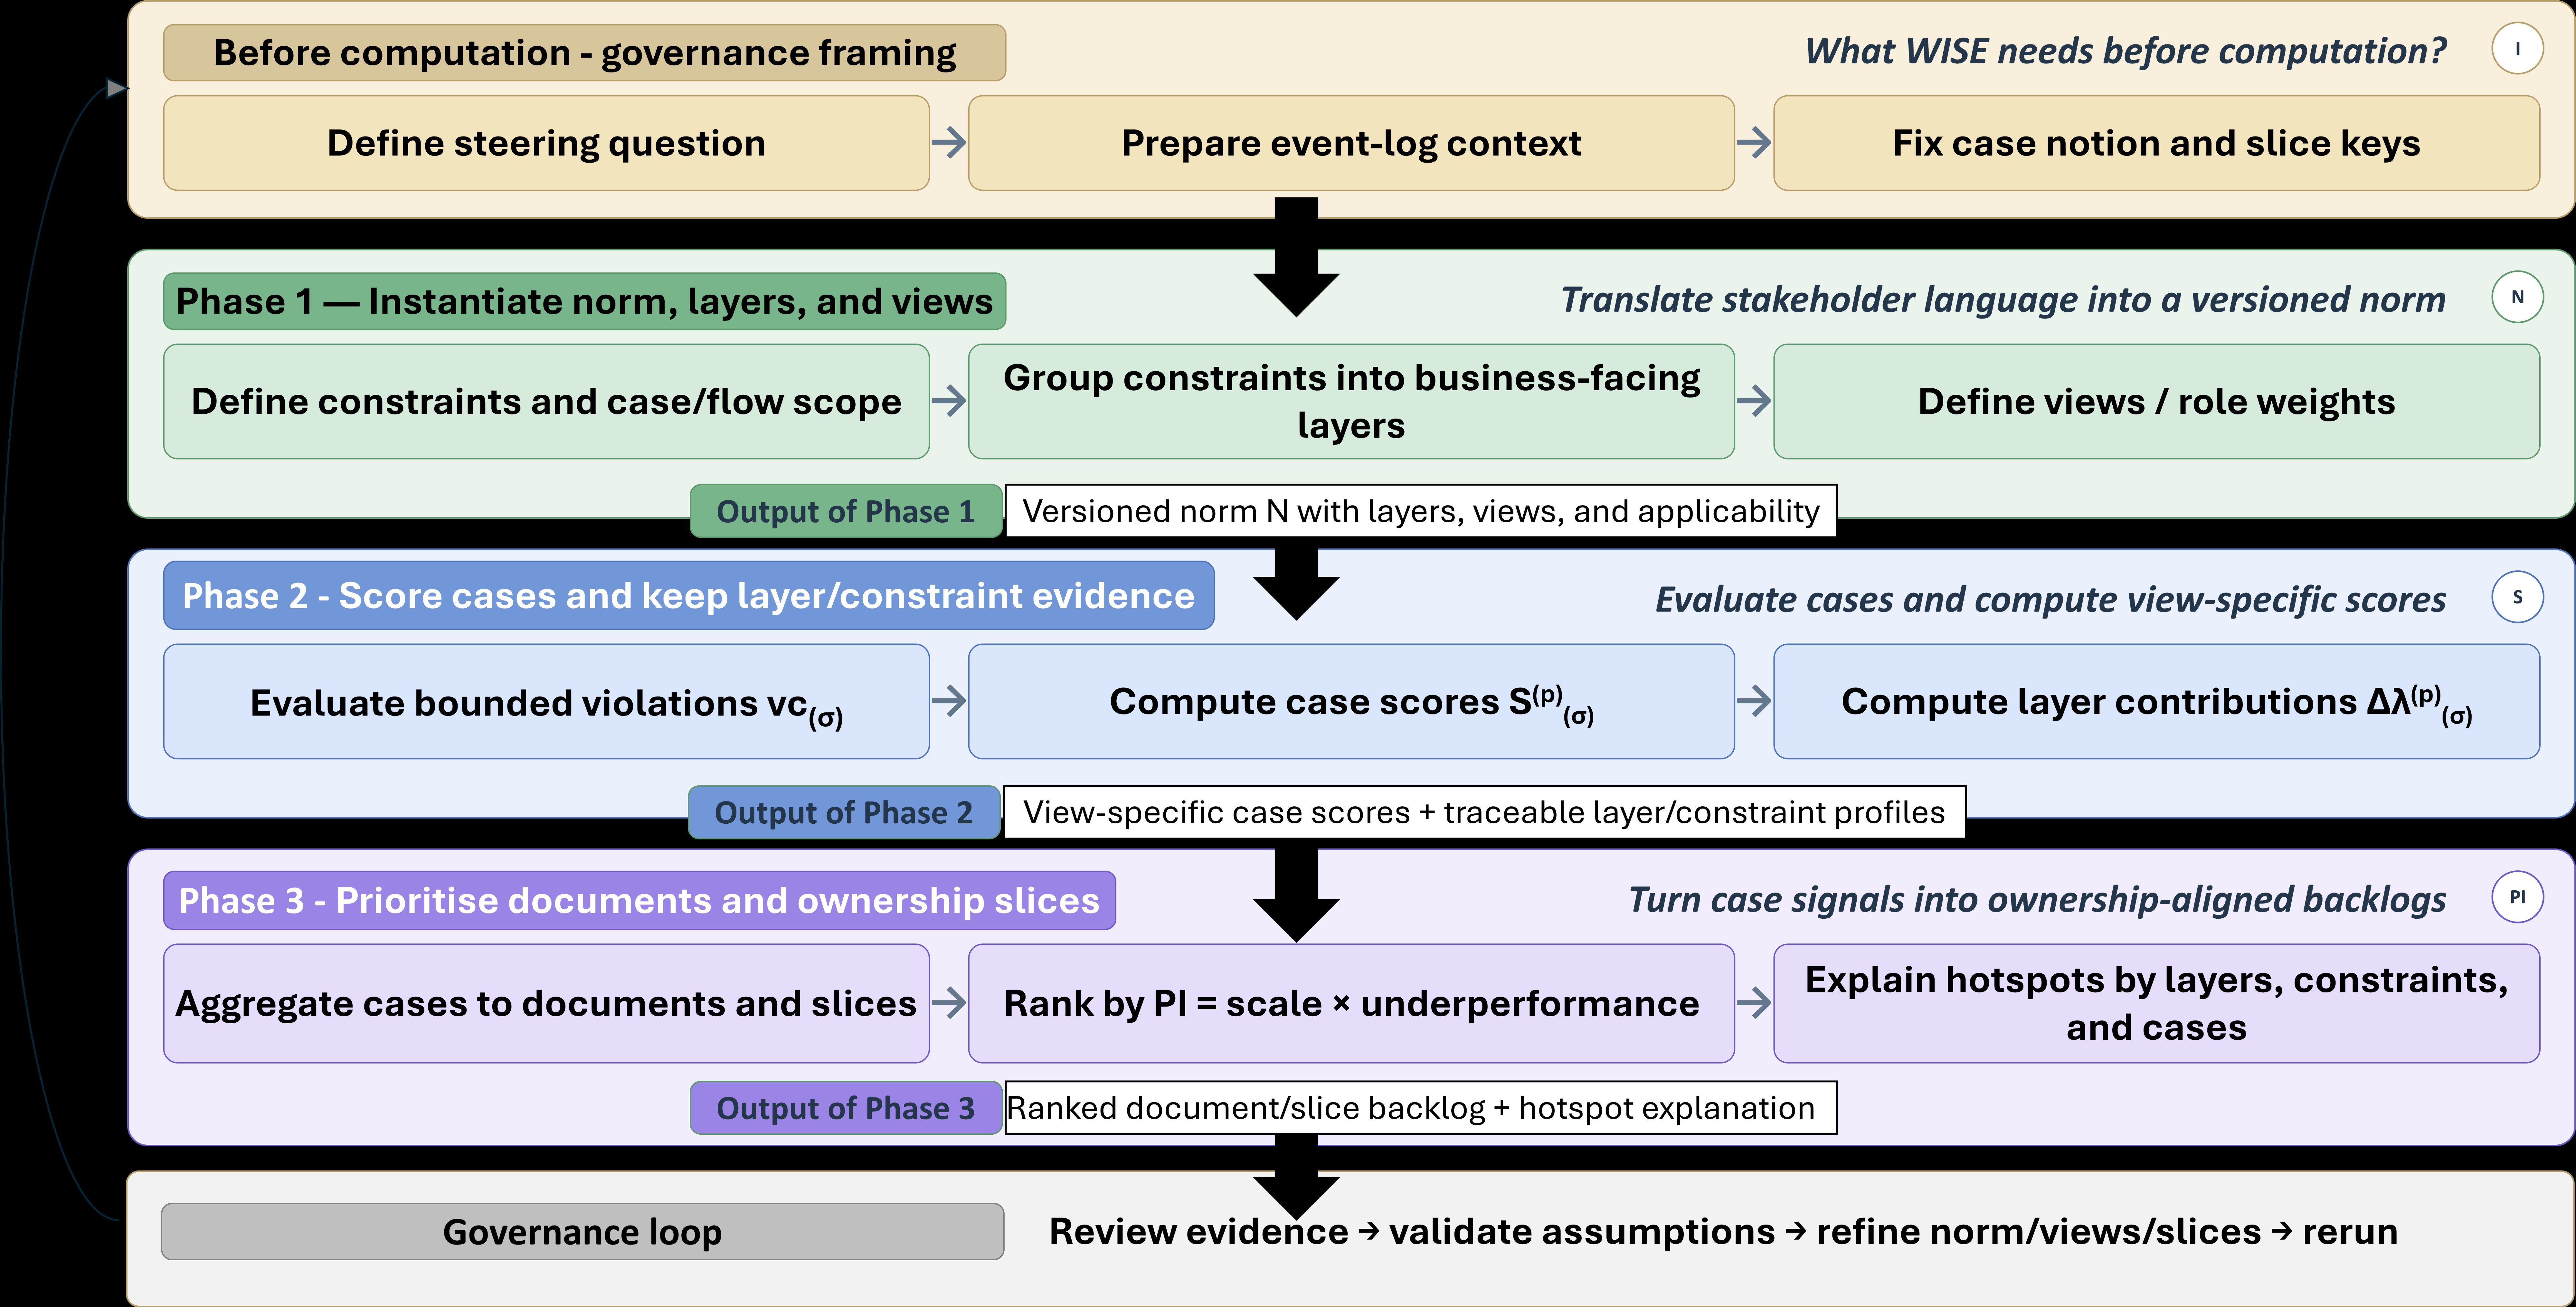

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===========================================================================
#  DATA LOCATION — the only thing you normally need to set.
#  Leave None  ->  the  data/  folder next to this notebook is used
#                  (any *.csv inside it is found automatically).
#  Or point it at your folder, e.g.  r"C:\Code\WISE_github\WISE\data"
# ===========================================================================
DATA_DIR_OVERRIDE = None

# --- locate the project root (folder containing wise_eval/) ---------------
import sys, os
from pathlib import Path

def _project_root():
    nb_path = globals().get("__vsc_ipynb_file__")
    if nb_path:
        p = Path(nb_path).resolve().parent
        if (p / "wise_eval" / "__init__.py").exists():
            return p
        if (p.parent / "wise_eval" / "__init__.py").exists():
            return p.parent
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "wise_eval" / "__init__.py").exists():
            return p
    for sub in sorted(Path.cwd().iterdir()):
        if sub.is_dir() and (sub / "wise_eval" / "__init__.py").exists():
            return sub
    raise FileNotFoundError("wise_eval/ not found — keep this notebook inside "
                            "the project folder and open that folder in VS Code/Jupyter.")

PROJECT_ROOT = _project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from wise_eval.config import CONFIG, RNG_SEED
from wise_eval import data as wdata, features as wfeat, norm as wnorm
from wise_eval import constraints as wcons, scoring as wsc
from wise_eval import prioritization as prio, governance as gov, viz

if DATA_DIR_OVERRIDE:
    CONFIG["csv_search_dirs"].insert(0, str(DATA_DIR_OVERRIDE))
    CONFIG["csv_candidates"].insert(0, str(Path(DATA_DIR_OVERRIDE) / "BPI_Challenge_2019.csv"))

# All figures of this notebook are written here (full load, every artefact):
CONFIG["figures_dir"] = str(PROJECT_ROOT / "figures" / "paper")
Path(CONFIG["figures_dir"]).mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200); pd.set_option("display.width", 240)
np.random.seed(RNG_SEED)
VIEWS = ["Finance", "Logistics", "Compliance", "Automation"]
print(f"project root : {PROJECT_ROOT}")
print(f"figures dir  : {CONFIG['figures_dir']}")


project root : /Users/ula/code/PhD/WISE/WISE/Untitled
figures dir  : /Users/ula/code/PhD/WISE/WISE/Untitled/figures/paper


## V-A — Governance framing
**Steering question (BPIC'19 Q3):** which purchase documents stand out, where are the
deviations and how severe, and which counterparties produce rework? Operationalised as
**Q3.1** stand-out documents, **Q3.2** deviations & mechanisms, **Q3.3** value/rework
concentration. **Case** σ = PO item; **governance unit** = PO header; **slicing**
g(σ) = company × spend area; flow types DF1/DF2/2-way/Consignment fix the
applicability map C_app.

In [2]:
# --- Load & prepare the event log (governance framing: fix the case notion) ---
df_raw, SOURCE, csv_path = wdata.load_raw_log()
df = wdata.prepare_log(df_raw)
n_docs = df["purchasing_document"].nunique()
print(f"\nData source : {SOURCE}" + (f"  ({csv_path})" if csv_path else "  (synthetic fallback with planted hotspots)"))
print(f"Event log   : {len(df):,} events | {df['case_id'].nunique():,} PO items | {n_docs:,} purchasing documents")
print("\nFlow-type case distribution (applicability backbone of the norm, paper Sec. V-A):")
flow_tab = (df.groupby("flow_type")["case_id"].nunique().rename("PO items")
            .to_frame().assign(share=lambda t: (t["PO items"]/t["PO items"].sum()).round(3)))
display(flow_tab)


[data] loading REAL BPIC'19 log: /Users/ula/code/PhD/WISE/WISE/Untitled/data/BPI_Challenge_2019.csv
[data] read 1,595,923 rows x 22 columns

Data source : BPIC19  (/Users/ula/code/PhD/WISE/WISE/Untitled/data/BPI_Challenge_2019.csv)
Event log   : 1,595,923 events | 251,734 PO items | 76,349 purchasing documents

Flow-type case distribution (applicability backbone of the norm, paper Sec. V-A):


,PO items,share
flow_type,,
2-way,1044,0.004
Consignment,14498,0.058
DF1,15182,0.060
DF2,221010,0.878


## V-B — Phases 1 & 2: norm, views, case scores
29 flow-aware constraints in 7 layers (L1 closure … L7 effort); four role-based views
(Table VIII layer weights). Every PO item gets a bounded violation per applicable
constraint, a score per view, and an **exact** layer decomposition
1 − S⁽ᵖ⁾ = Σ_λ Δλ.

In [3]:
# --- Phases 1+2: norm, bounded violations ν_c(σ), view scores S^(p)(σ), layer contributions Δλ ---
fc   = wfeat.build_case_features(df)
norm = wnorm.load_norm()
dfv, V, M = wcons.build_violation_matrix(fc, norm)
dflp = wsc.compute_layer_penalties(dfv, norm)
dvs, dcontrib = wsc.compute_view_scores(dflp, norm)
scores = wsc.assemble_case_scores(fc, dfv, dflp, dvs, dcontrib)

print(f"Norm: {len(norm['constraints'])} constraints in {len(norm['layers'])} layers | "
      f"V (cases × constraints): {V.shape} | applicability density M̄ = {M.mean():.1%}")
print("\nGLOBAL BASELINES μ̄^(p)   [paper Sec. V-B: 0.82 / 0.82 / 0.87 / 0.84]")
for v in VIEWS:
    s = scores[f"score__{v}"].dropna()
    print(f"  μ̄^({v:<10}) = {s.mean():.3f}   (mean weighted violation {1-s.mean():.1%}, {len(s):,} scored cases)")
chk = max(abs(scores[[c for c in scores.columns if c.startswith("contrib__Finance__")]].sum(axis=1)
              - (1 - scores["score__Finance"])).max(), 0)
print(f"\nExact layer decomposition check (Finance): max |Σ_λ Δλ − (1−S)| = {chk:.2e}  ✓")


Norm: 29 constraints in 7 layers | V (cases × constraints): (251734, 29) | applicability density M̄ = 76.2%

GLOBAL BASELINES μ̄^(p)   [paper Sec. V-B: 0.82 / 0.82 / 0.87 / 0.84]
  μ̄^(Finance   ) = 0.819   (mean weighted violation 18.1%, 251,734 scored cases)
  μ̄^(Logistics ) = 0.817   (mean weighted violation 18.3%, 251,734 scored cases)
  μ̄^(Compliance) = 0.871   (mean weighted violation 12.9%, 251,734 scored cases)
  μ̄^(Automation) = 0.844   (mean weighted violation 15.6%, 251,734 scored cases)

Exact layer decomposition check (Finance): max |Σ_λ Δλ − (1−S)| = 1.67e-16  ✓


In [4]:
# --- The four view-independent global signals of paper Sec. V-C (Q3.2) ----
def _cnt(col):
    return scores[col].fillna(0) if col in scores.columns else pd.Series(0.0, index=scores.index)

inv_flows  = scores["flow_type"].isin(["DF1", "DF2", "2-way"])      # invoicing expected
three_way  = scores["flow_type"].isin(["DF1", "DF2"])               # GR/SES expected
has_inv    = (_cnt("count__record_invoice_receipt") + _cnt("count__vendor_creates_invoice")) > 0
has_clear  = _cnt("count__clear_invoice") > 0
has_grses  = (_cnt("count__record_goods_receipt") + _cnt("count__record_service_entry_sheet")) > 0

s1 = (inv_flows & ~has_clear).sum() / max(inv_flows.sum(), 1)        # open / missing closure
age_col = next((c for c in scores.columns if "invoice_to_clear" in c and c.startswith("c_")), None)
age = scores[age_col] if age_col else pd.Series(dtype=float)
s2 = (age > 0).sum() / max(age.notna().sum(), 1)                     # positive IR→CI ageing
s3 = (inv_flows & ~has_inv).sum() / max(inv_flows.sum(), 1)          # missing invoice evidence
s4 = (three_way & ~has_grses).sum() / max(three_way.sum(), 1)        # missing GR/SES

print("GLOBAL MECHANISM SIGNALS (view-independent)              [paper, real log]")
print(f"  1. {s1:6.1%} of invoice-bearing items never reach Clear Invoice        [22.6%]  → L1 closure")
print(f"  2. {s2:6.1%} of applicable items show positive IR→CI ageing severity   [68.7%]  → L3 ageing")
print(f"  3. {s3:6.1%} of invoice-bearing items lack invoice evidence            [10.9%]  → L1 completeness")
print(f"  4. {s4:6.1%} of 3-way items lack GR/SES evidence                       [ 6.4%]  → L1 completeness")

print("\nDOMINANT WEIGHTED LAYER PER VIEW (mean Δλ over all cases)  "
      "[paper: L3 for Fin/Log/Compl, L7 for Automation]")
dom_rows = {}
for v in VIEWS:
    m = scores[[f"contrib__{v}__{l}" for l in norm["layers"]]].mean()
    m.index = list(norm["layers"].keys())
    dom_rows[v] = m
layer_dom = pd.DataFrame(dom_rows)
layer_dom.index = [f"{l} {norm['layers'][l]['name']}" for l in layer_dom.index]
display(layer_dom.round(4))
for v in VIEWS:
    print(f"  {v:<10} → dominant layer: {layer_dom[v].idxmax()}")


GLOBAL MECHANISM SIGNALS (view-independent)              [paper, real log]
  1.  22.6% of invoice-bearing items never reach Clear Invoice        [22.6%]  → L1 closure
  2.  88.9% of applicable items show positive IR→CI ageing severity   [68.7%]  → L3 ageing
  3.  10.9% of invoice-bearing items lack invoice evidence            [10.9%]  → L1 completeness
  4.   6.4% of 3-way items lack GR/SES evidence                       [ 6.4%]  → L1 completeness

DOMINANT WEIGHTED LAYER PER VIEW (mean Δλ over all cases)  [paper: L3 for Fin/Log/Compl, L7 for Automation]


,Finance,Logistics,Compliance,Automation
L1_closure_completeness Expected completion and closure,0.0456,0.0188,0.0255,0.0095
L2_flow_discipline Flow-conditioned control discipline,0.0020,0.0059,0.0073,0.0020
L3_timeliness_ageing Handovers and ageing,0.1078,0.1123,0.0541,0.0449
L4_rework_instability Rework and instability,0.0010,0.0041,0.0011,0.0043
L5_exceptions_corrections Exceptions and corrections,0.0019,0.0023,0.0070,0.0013
L6_value_commercial Value and commercial integrity,0.0054,0.0010,0.0015,0.0017
L7_effort_automation Effort and automation friction,0.0173,0.0386,0.0328,0.0920


  Finance    → dominant layer: L3_timeliness_ageing Handovers and ageing
  Logistics  → dominant layer: L3_timeliness_ageing Handovers and ageing
  Compliance → dominant layer: L3_timeliness_ageing Handovers and ageing
  Automation → dominant layer: L7_effort_automation Effort and automation friction


## Q3.1 — Stand-out documents (paper **Fig. 4**)
Item scores roll up to PO headers; headers are ranked by shrinkage-stabilised PI.
The paper reports: *2–3 % of PO headers capture 80 % of stable PI, <10 % capture
95 %* and shows the **Compliance** view as the representative curve.

BACKLOG CONCENTRATION PER VIEW            [paper: 2–3% capture 80%, <10% capture 95%]
  Finance   :  2,039 headers =  2.7% capture 80%   |    7,643 = 10.0% capture 95%
  Logistics :  2,110 headers =  2.8% capture 80%   |    7,420 =  9.7% capture 95%
  Compliance:  1,771 headers =  2.3% capture 80%   |    7,012 =  9.2% capture 95%
  Automation:  2,083 headers =  2.7% capture 80%   |    7,722 = 10.1% capture 95%


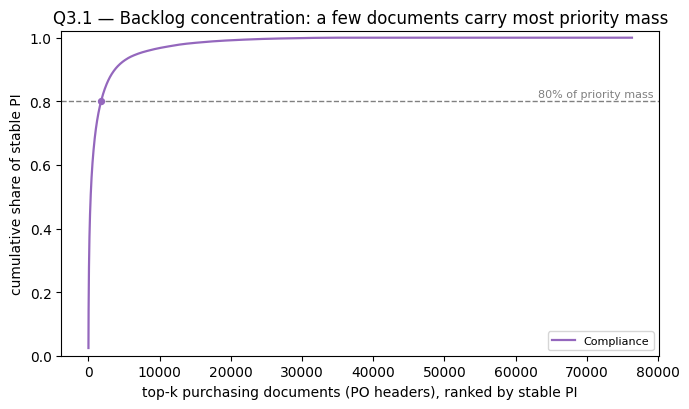

In [5]:
doc_backlogs, doc_cums = {}, {}
print("BACKLOG CONCENTRATION PER VIEW            [paper: 2–3% capture 80%, <10% capture 95%]")
for v in VIEWS:
    bl = prio.document_backlog(scores, v)
    conc, cum = prio.pareto_concentration(bl)
    doc_backlogs[v], doc_cums[v] = bl, cum
    (k80, s80), (k95, s95) = conc[0.80], conc[0.95]
    print(f"  {v:<10}: {k80:>6,} headers = {s80:5.1%} capture 80%   |   {k95:>6,} = {s95:5.1%} capture 95%")

# Paper Fig. 4 — Compliance as the representative view
viz.fig_document_pareto({"Compliance": doc_cums["Compliance"]},
                        name="fig04_document_pareto_compliance");


In [6]:
# View overlap — paper finding 6 [Jaccard top-20: Fin–Compl 0.481 vs Fin–Aut 0.081;
#                                  score correlations 0.817 / 0.572]
jac = prio.jaccard_topk(doc_backlogs, k=CONFIG["top_k_documents"])
corr = scores[[f"score__{v}" for v in VIEWS]].corr()
corr.index = corr.columns = VIEWS
print(f"Top-{CONFIG['top_k_documents']} document Jaccard overlap:"); display(jac.round(3))
print("Item-population score correlations:"); display(corr.round(3))
print(f"\nPASTE-READY → 'Finance and Compliance have a top-20 document Jaccard overlap of "
      f"{jac.loc['Finance','Compliance']:.3f}, whereas Finance and Automation overlap at only "
      f"{jac.loc['Finance','Automation']:.3f}; their item-population score correlations are "
      f"{corr.loc['Finance','Compliance']:.3f} and {corr.loc['Finance','Automation']:.3f}, respectively.'")


Top-20 document Jaccard overlap:


,Finance,Logistics,Compliance,Automation
Finance,1.000,0.143,0.481,0.081
Logistics,0.143,1.000,0.212,0.250
Compliance,0.481,0.212,1.000,0.143
Automation,0.081,0.250,0.143,1.000


Item-population score correlations:


,Finance,Logistics,Compliance,Automation
Finance,1.000,0.782,0.817,0.570
Logistics,0.782,1.000,0.767,0.771
Compliance,0.817,0.767,1.000,0.617
Automation,0.570,0.771,0.617,1.000



PASTE-READY → 'Finance and Compliance have a top-20 document Jaccard overlap of 0.481, whereas Finance and Automation overlap at only 0.081; their item-population score correlations are 0.817 and 0.570, respectively.'


## Q3.1/Q3.2 — Focus slices (paper **Table IX**) and risk matrix (paper **Fig. 5**)
The paper's three Automation-view exemplars: `companyID_0000 × Packaging` (reservoir),
`companyID_0000 × Logistics` (mechanism), `companyID_0003 × Real Estate` (severity).
If a slice is absent (e.g. on synthetic data), the typed backlog supplies a
same-type stand-in.

TABLE IX (live) — focus slices, Automation view
[paper: Packaging 109,199 / 0.0088 / 963.1 · Logistics 5,242 / 0.0463 / 242.4 · Real Estate 583 / 0.0868 / 50.6]


,Slice,Cases,Stable gap,Stable PI,Hotspot type,Dominant layer delta,Leading constraint
0,companyID_0000 × Packaging,109199,0.0087,945.7,reservoir,L3_timeliness_ageing Handovers and ageing,c_l3_invoice_to_clear_days
1,companyID_0000 × Logistics,5242,0.0561,294.2,mechanism,L4_rework_instability Rework and instability,c_l4_goods_fragmentation
2,companyID_0003 × Real Estate,583,0.0869,50.6,severity,L4_rework_instability Rework and instability,c_l4_change_approval_repeats


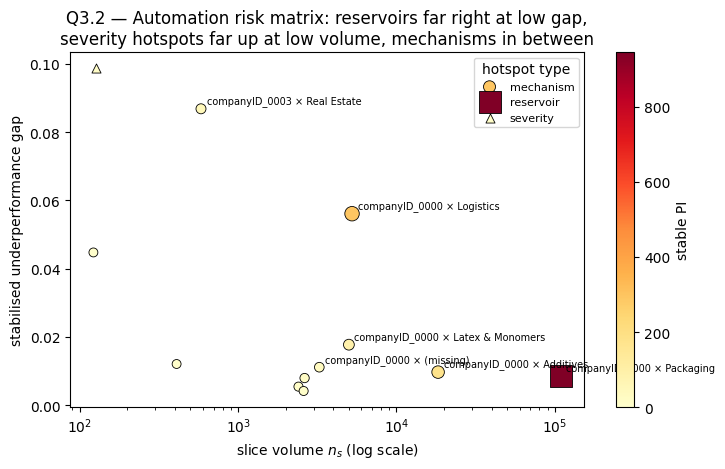

In [7]:
SLICE_KEYS = CONFIG["slice_keys"]
backlog = prio.slice_backlog(scores, "Automation", SLICE_KEYS)
typed   = prio.classify_hotspots(backlog, top_n=12)

PAPER_TRIO = [("companyID_0000", "Packaging"), ("companyID_0000", "Logistics"),
              ("companyID_0003", "Real Estate")]
PAPER_TYPE = ["reservoir", "mechanism", "severity"]

def _present(sl):
    m = (backlog[SLICE_KEYS[0]] == sl[0]) & (backlog[SLICE_KEYS[1]] == sl[1])
    return backlog.loc[m].iloc[0] if m.any() else None

focus_slices, focus_rows = [], []
for sl, typ in zip(PAPER_TRIO, PAPER_TYPE):
    row = _present(sl)
    if row is None:  # synthetic fallback: first slice of that hotspot type
        cand = typed[typed["hotspot_type"] == typ]
        if len(cand) == 0: continue
        row = cand.iloc[0]; sl = tuple(row[k] for k in SLICE_KEYS)
    focus_slices.append(sl); focus_rows.append((sl, typ, row))

tab9 = []
for sl, typ, row in focus_rows:
    mask = (scores[SLICE_KEYS[0]] == sl[0]) & (scores[SLICE_KEYS[1]] == sl[1])
    deltas = prio.slice_layer_deltas(scores, "Automation", SLICE_KEYS, norm)
    drow = deltas.loc[sl]
    dom_layer = drow.idxmax()
    lead = gov_lead = prio.leading_constraint(scores, mask, dom_layer, norm).index[0]
    tab9.append({"Slice": " × ".join(map(str, sl)), "Cases": int(row["cases"]),
                 "Stable gap": round(float(row["stable_gap"]), 4),
                 "Stable PI": round(float(row["PI_stable"]), 1), "Hotspot type": typ,
                 "Dominant layer delta": f"{dom_layer} {norm['layers'][dom_layer]['name']}",
                 "Leading constraint": lead})
TAB9 = pd.DataFrame(tab9)
print("TABLE IX (live) — focus slices, Automation view")
print("[paper: Packaging 109,199 / 0.0088 / 963.1 · Logistics 5,242 / 0.0463 / 242.4 · Real Estate 583 / 0.0868 / 50.6]")
display(TAB9)

viz.fig_risk_matrix(typed, SLICE_KEYS, "Automation", name="fig05_risk_matrix_automation");


## Q3.2 — Layer-delta profiles (paper **Fig. 6**) and lag drill-down (paper **Fig. 7**, placeholder)
Fig. 6 explains *why* each focus slice is prioritised. Fig. 7 fills the paper's ECDF
placeholder and prints the verdict sentence the running text asks to insert.

Layer deltas vs global (positive = mechanism more pronounced in the slice):


L1_closure_completeness  L2_flow_discipline  L3_timeliness_ageing  L4_rework_instability  L5_exceptions_corrections  L6_value_commercial  L7_effort_automation
case Company   case Spend area text                                                                                                                                                                
companyID_0000 Packaging                             -0.0007             -0.0001                0.0111                -0.0024                    -0.0003              -0.0005                0.0016
               Logistics                              0.0243              0.0033               -0.0283                 0.0645                     0.0005               0.0096               -0.0175
companyID_0003 Real Estate                            0.0237             -0.0020               -0.0387                 0.0827                    -0.0009              -0.0014                0.0264

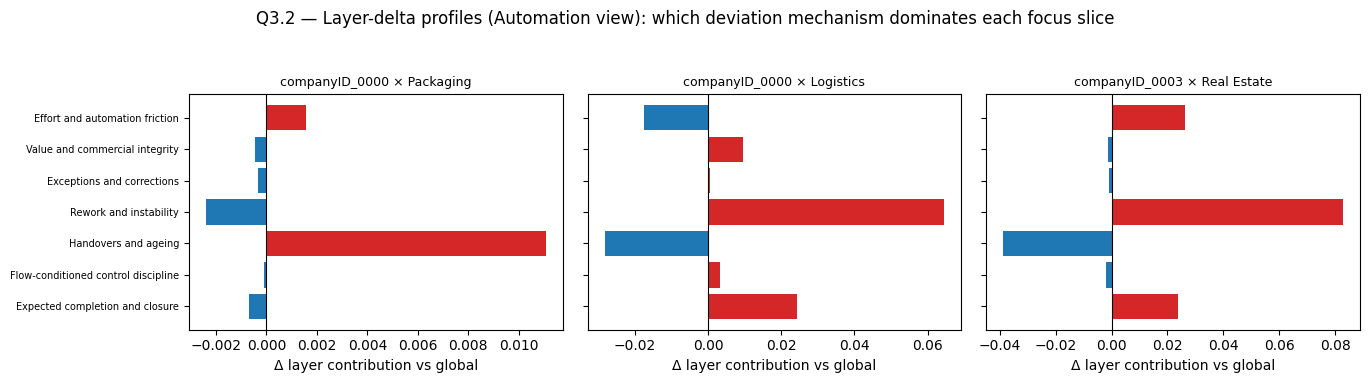

In [8]:
deltas_all = prio.slice_layer_deltas(scores, "Automation", SLICE_KEYS, norm)
focus_deltas = deltas_all.loc[focus_slices]
viz.fig_layer_deltas(focus_deltas, norm, "Automation", name="fig06_layer_deltas_automation")
print("Layer deltas vs global (positive = mechanism more pronounced in the slice):")
display(focus_deltas.round(4))


PASTE-READY → 'In our run, the in-slice distribution shows a median of 83 days versus 55 days for the rest of the log (shift ×1.52; p90/median 1.36 vs 1.58), i.e. body-wide shift → systemic queue problem (SLA/escalation/workload rebalancing).'


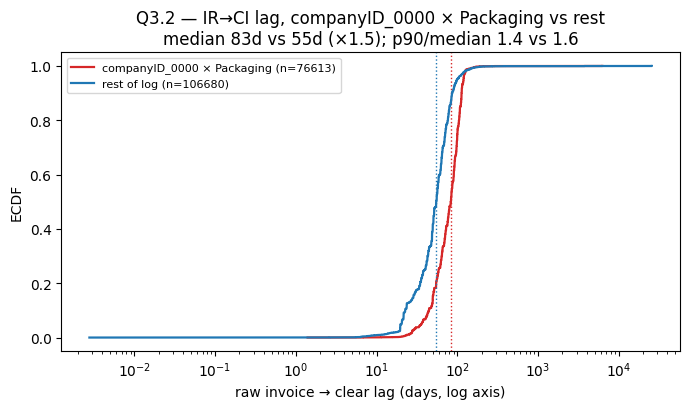

In [9]:
# Fig. 7 — ECDF of the raw IR→CI lag: reservoir slice vs rest of log
inv_cols = [c for c in ("first_ts__record_invoice_receipt", "first_ts__vendor_creates_invoice")
            if c in scores.columns]
inv_ts = scores[inv_cols].min(axis=1)
lag_days = (scores.get("first_ts__clear_invoice") - inv_ts).dt.total_seconds() / 86400
lag_days = lag_days.where(lag_days > 0)

res_slice = focus_slices[0]
in_mask = (scores[SLICE_KEYS[0]] == res_slice[0]) & (scores[SLICE_KEYS[1]] == res_slice[1])
fig, verdict = viz.fig_lag_ecdf(lag_days[in_mask], lag_days[~in_mask],
                                " × ".join(map(str, res_slice)), name="fig07_lag_ecdf_packaging")
print(f"PASTE-READY → 'In our run, the in-slice distribution shows a median of "
      f"{verdict['median_in']:.0f} days versus {verdict['median_out']:.0f} days for the rest of "
      f"the log (shift ×{verdict['shift_ratio']:.2f}; p90/median {verdict['tail_in']:.2f} vs "
      f"{verdict['tail_out']:.2f}), i.e. {verdict['verdict']}.'")


## Q3.3 — Ownership heatmap (paper **Fig. 8**) and vendor Pareto (paper **Fig. 9**, placeholder)
Fig. 8 uses the **Compliance** view as in the paper; Fig. 9 answers *which customers
produce a lot of rework* one level deeper, inside the mechanism hotspot.

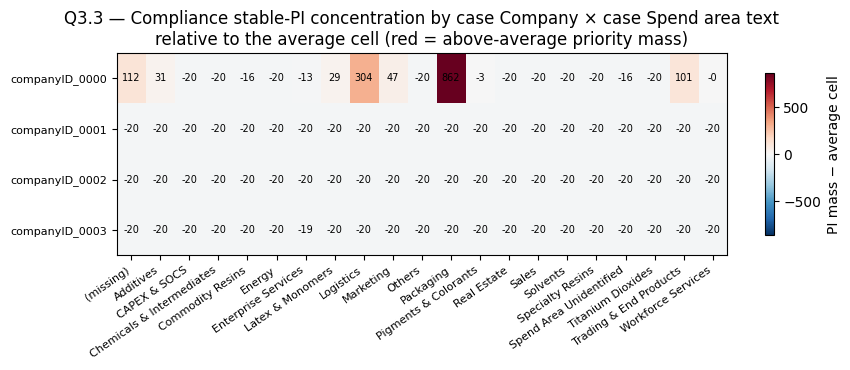

In [10]:
backlog_compl = prio.slice_backlog(scores, "Compliance", SLICE_KEYS)
viz.fig_ownership_heatmap(backlog_compl, SLICE_KEYS, "Compliance",
                          name="fig08_ownership_heatmap_compliance");


PASTE-READY → 'In our run, 22 of 128 vendors inside the slice carry 80% of its penalty mass.'

Leading counterparties:


,penalty
case Vendor,
vendorID_0470,85.84
vendorID_0235,64.42
vendorID_0472,64.32
vendorID_0471,62.52
vendorID_0364,60.96
vendorID_0230,56.13
vendorID_0233,55.79
vendorID_0234,55.15


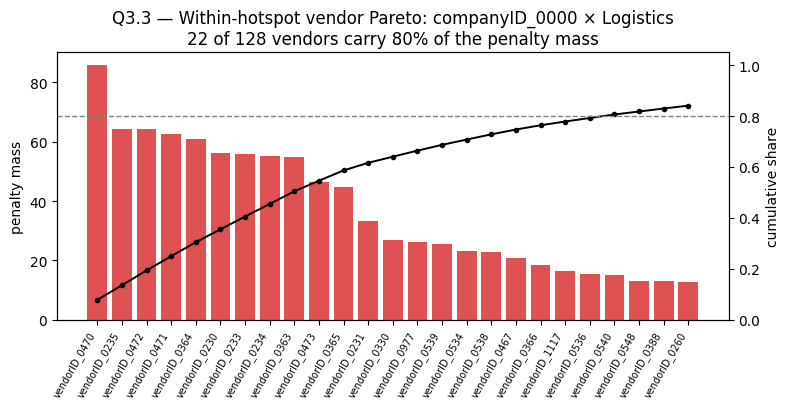

In [11]:
mech_slice = focus_slices[1] if len(focus_slices) > 1 else focus_slices[0]
m = (scores[SLICE_KEYS[0]] == mech_slice[0]) & (scores[SLICE_KEYS[1]] == mech_slice[1])
pen = (1 - scores.loc[m, "score__Automation"]).rename("penalty")
vend = pen.groupby(scores.loc[m, "case Vendor"]).sum().sort_values(ascending=False)
fig, kk = viz.fig_vendor_pareto(vend, " × ".join(map(str, mech_slice)), name="fig09_vendor_pareto_logistics")
print(f"PASTE-READY → 'In our run, {kk['k']} of {kk['K']} vendors inside the slice carry "
      f"{kk['threshold']:.0%} of its penalty mass.'")
print("\nLeading counterparties:"); display(vend.head(8).round(2).to_frame())


## Governance loop — paper **Table X** (real numbers) and **Fig. 10** (placeholder)
Three diagnostics separate *likely process issues* from *likely measurement issues*:
right-censoring, event replication, and gap-retained-excluding-censored.

In [12]:
d = gov.add_governance_flags(scores)
TAB10 = gov.governance_table(d, "Automation", focus_slices, SLICE_KEYS)
print("TABLE X (live) — governance-loop validation of the focus slices:")
display(TAB10)

# Sentences the paper text needs (the 'xx%' fills):
viol_closure = (scores["flow_type"].isin(["DF1","DF2","2-way"])
                & (scores.get("count__clear_invoice", pd.Series(0, index=scores.index)).fillna(0) == 0))
cens_among_viol = d.loc[viol_closure, "is_right_censored"].mean()
rep_mech = d.loc[(d[SLICE_KEYS[0]] == mech_slice[0]) & (d[SLICE_KEYS[1]] == mech_slice[1]),
                 "event_replication_ratio"].mean()
ret = " / ".join(f"{x:.0%}" for x in TAB10["gap_retained_excl_censored"])
print(f"\nPASTE-READY → '{cens_among_viol:.0%} of the items violating the closure constraint are right-censored.'")
print(f"PASTE-READY → 'the focus-slice gaps are retained at {ret} when censored items are excluded.'")
print(f"PASTE-READY → 'the fragmentation pattern co-occurs with an elevated event-replication ratio of {rep_mech:.2f}.'")


TABLE X (live) — governance-loop validation of the focus slices:


,focus_slice,cases,right_censored_share,replicated_event_share,stable_gap_all,stable_gap_excl_censored,gap_retained_excl_censored,reading
0,companyID_0000 × Packaging,109199,0.0,0.000000,0.008661,0.008661,1.0,gap largely retained → hotspot is not a window...
1,companyID_0000 × Logistics,5242,0.0,0.725486,0.056119,0.056119,1.0,gap largely retained → hotspot is not a window...
2,companyID_0003 × Real Estate,583,0.0,0.000000,0.086858,0.086858,1.0,gap largely retained → hotspot is not a window...



PASTE-READY → '0% of the items violating the closure constraint are right-censored.'
PASTE-READY → 'the focus-slice gaps are retained at 100% / 100% / 100% when censored items are excluded.'
PASTE-READY → 'the fragmentation pattern co-occurs with an elevated event-replication ratio of 6.42.'


Censoring-affected quarters (shaded): []


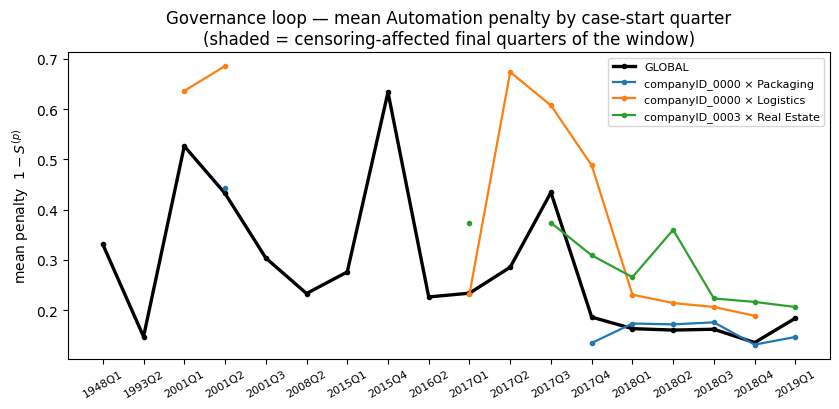

In [13]:
trend = gov.quarterly_penalty_trend(d, "Automation", focus_slices, SLICE_KEYS)
window_end = d["_window_end"].iloc[0]
horizon = window_end - pd.Timedelta(days=CONFIG["censoring_window_days"])
censor_q = [q for q in trend.index if pd.Period(q).end_time >= horizon]
viz.fig_quarterly_trend(trend, censor_q, "Automation", name="fig10_quarterly_trend_automation")
print(f"Censoring-affected quarters (shaded): {censor_q}")


In [14]:
# TABLE XI (live) — the seven principal findings with this run's numbers
conc_c, _ = prio.pareto_concentration(doc_backlogs["Compliance"])
TAB11 = pd.DataFrame([
 {"#":1, "Finding":"Deviation priority is strongly concentrated",
  "Key evidence (this run)": f"{conc_c[0.80][1]:.1%} of PO headers capture 80% of stable PI, "
                             f"{conc_c[0.95][1]:.1%} capture 95% (Compliance view; Fig. 4)"},
 {"#":2, "Finding":"Dominant global mechanisms are closure and ageing",
  "Key evidence (this run)": f"{s1:.1%} of invoice-bearing items miss Clear Invoice; "
                             f"{s2:.1%} show positive IR→CI ageing; dominant layers per view as printed above"},
 {"#":3, "Finding":"High priority arises for three different reasons",
  "Key evidence (this run)": "; ".join(f"{r['Hotspot type']}: {r['Slice']} ({r['Cases']:,} cases, gap {r['Stable gap']})"
                                        for _, r in TAB9.iterrows()) + " (Table IX, Figs. 5–6)"},
 {"#":4, "Finding":"Mechanism shape discriminates the intervention",
  "Key evidence (this run)": f"IR→CI ECDF: median ×{verdict['shift_ratio']:.2f} shift → {verdict['verdict']} (Fig. 7)"},
 {"#":5, "Finding":"Priority mass localises to nameable owners/counterparties",
  "Key evidence (this run)": f"{kk['k']} of {kk['K']} vendors carry 80% of the {' × '.join(map(str, mech_slice))} penalty (Figs. 8–9)"},
 {"#":6, "Finding":"Stakeholder views change the practical shortlist",
  "Key evidence (this run)": f"Top-20 Jaccard {jac.loc['Finance','Compliance']:.3f} (Fin–Compl) vs "
                             f"{jac.loc['Finance','Automation']:.3f} (Fin–Aut); correlations "
                             f"{corr.loc['Finance','Compliance']:.3f} / {corr.loc['Finance','Automation']:.3f}"},
 {"#":7, "Finding":"Findings are robust to / qualified by data-semantics risks",
  "Key evidence (this run)": f"gaps retained at {ret} excl. censored; {cens_among_viol:.0%} of closure violations "
                             f"censored; replication ratio {rep_mech:.2f} in the mechanism hotspot (Table X, Fig. 10)"},
]).set_index("#")
print("TABLE XI (live) — summary of the evaluation:")
display(TAB11)


TABLE XI (live) — summary of the evaluation:


,Finding,Key evidence (this run)
#,,
1,Deviation priority is strongly concentrated,"2.3% of PO headers capture 80% of stable PI, 9..."
2,Dominant global mechanisms are closure and ageing,22.6% of invoice-bearing items miss Clear Invo...
3,High priority arises for three different reasons,"reservoir: companyID_0000 × Packaging (109,199..."
4,Mechanism shape discriminates the intervention,IR→CI ECDF: median ×1.52 shift → body-wide shi...
5,Priority mass localises to nameable owners/cou...,22 of 128 vendors carry 80% of the companyID_0...
6,Stakeholder views change the practical shortlist,Top-20 Jaccard 0.481 (Fin–Compl) vs 0.081 (Fin...
7,Findings are robust to / qualified by data-sem...,gaps retained at 100% / 100% / 100% excl. cens...


---
# 📌 Paper placement guide — what goes where

| Artefact (this notebook) | File in `figures/paper/` | Goes into the paper as | Section |
|---|---|---|---|
| Document Pareto, Compliance | `fig04_document_pareto_compliance.png` | **Fig. 4** | V-C, Q3.1 |
| Automation risk matrix | `fig05_risk_matrix_automation.png` | **Fig. 5** | V-C, Q3.1/Q3.2 |
| Layer-delta profiles, 3 focus slices | `fig06_layer_deltas_automation.png` | **Fig. 6** | V-C, Q3.2 |
| IR→CI lag ECDF, reservoir vs rest | `fig07_lag_ecdf_packaging.png` | **Fig. 7** — *replaces the ECDF placeholder* | V-C, Q3.2 |
| Compliance ownership heatmap | `fig08_ownership_heatmap_compliance.png` | **Fig. 8** | V-C, Q3.3 |
| Within-hotspot vendor Pareto | `fig09_vendor_pareto_logistics.png` | **Fig. 9** — *replaces the vendor-Pareto placeholder* | V-C, Q3.3 |
| Quarterly penalty trend | `fig10_quarterly_trend_automation.png` | **Fig. 10** — *replaces the quarterly-trend placeholder* | V-C, governance loop |

**Tables.** The printed *Table IX (live)* supplies/verifies the numbers of paper
**Table IX**; *Table X (live)* fills every `xx%` cell of paper **Table X** (plus its
auto-generated *Reading* column); *Table XI (live)* fills the `xx` evidence cells of
paper **Table XI** (findings 1, 4, 5, 7).

**Running-text fills (PASTE-READY lines printed above).** ① Fig. 7 paragraph: the
*median shift / tail ratio* verdict sentence. ② Fig. 9 paragraph: the *k of K vendors
carry 80 %* sentence. ③ Governance paragraph: the *% of closure violations
right-censored*, the *gaps retained at …* fractions, and the *event-replication ratio
of …* for the mechanism hotspot. ④ Finding 6 paragraph: the Jaccard/correlation
sentence printed under the overlap matrices.

For supplementary cross-view material (all four Pareto curves, risk matrices,
heatmaps, trends, per-view backlogs), run **`WISE_BPIC19_full_analysis.ipynb`** —
it writes the complete figure load to `figures/full/`.